# 04 - Spatial Niche Analysis

This notebook covers:
1. Spatial neighborhood graph construction
2. Neighborhood enrichment analysis
3. Co-occurrence analysis
4. Spatial niche identification

**Input:** `adata_deconv.h5ad` from notebook 03

## Setup

In [1]:
import sys
sys.path.append('..')

import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans

from src import preprocessing, visualization, utils

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white')

%matplotlib inline

/bigdata/godziklab/shared/Xinru/envs/spatial-kidney/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/bigdata/godziklab/shared/Xinru/envs/spatial-kidney/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/bigdata/godziklab/shared/Xinru/envs/spatial-kidney/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text in

In [2]:
# Paths
BASE_DIR = Path('/bigdata/godziklab/shared/Xinru/302031-spatial-kidney')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
TABLES_DIR = BASE_DIR / 'results' / 'tables'

## 1. Load Data

In [3]:
# Load data with deconvolution results
adata = sc.read_h5ad(PROCESSED_DIR / 'adata_deconv.h5ad')
print(f"Loaded data: {adata.shape}")
adata

Loaded data: (3431, 18027)


AnnData object with n_obs × n_vars = 3431 × 18027
    obs: 'sample', 'condition', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_0.3', 'leiden_0.5', 'leiden_0.8', 'leiden_1.0', 'leiden', 'Proximal_Tubule_score', 'Loop_of_Henle_score', 'Distal_Tubule_score', 'Collecting_Duct_PC_score', 'Collecting_Duct_IC_score', 'Podocyte_score', 'Endothelial_score', 'Mesangial_score', 'Fibroblast_score', 'Macrophage_score', 'T_Cell_score', 'B_Cell_score', 'NK_Cell_score', 'Plasma_Cell_score', 'Proximal_Tubule_prop', 'Loop_of_Henle_prop', 'Distal_Tubule_prop', 'Collecting_Duct_PC_prop', 'Collecting_Duct_IC_prop', 'Podocyte_prop', 'Endothelial_prop', 'Mesangial_prop', 'Fibroblast_prop', 'Macrophage_prop', 'T_Cell_prop', 'B_Cell_prop', 'NK_Cell_prop', 'Plasma_Cell_prop'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 

## 2. Spatial Neighborhood Graph

In [4]:
# Build spatial neighbor graph for each sample
samples = adata.obs['sample'].unique()

for sample in samples:
    print(f"Processing {sample}...")
    mask = adata.obs['sample'] == sample
    
    # Build spatial neighbors
    sq.gr.spatial_neighbors(
        adata[mask],
        coord_type='generic',
        n_neighs=6
    )

# For full dataset
sq.gr.spatial_neighbors(adata, coord_type='generic', n_neighs=6)
print("\nSpatial neighbor graph constructed")

Processing GSM9155022_control_58055...
Creating graph using `generic` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)
Processing GSM9155023_active_AMR_58056...
Creating graph using `generic` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)
Processing GSM9155025_chronic_active_AMR_58058...
Creating graph using `generic` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)
Processing GSM9155024_acute_TCMR_58057...
Creating graph using `generic` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obs

## 3. Neighborhood Enrichment Analysis

In [5]:
# Compute neighborhood enrichment for clusters
sq.gr.nhood_enrichment(adata, cluster_key='leiden')

Calculating neighborhood enrichment using `1` core(s)


  0%|          | 0/1000 [00:00<?, ?/s]

Adding `adata.uns['leiden_nhood_enrichment']`
Finish (0:00:00)


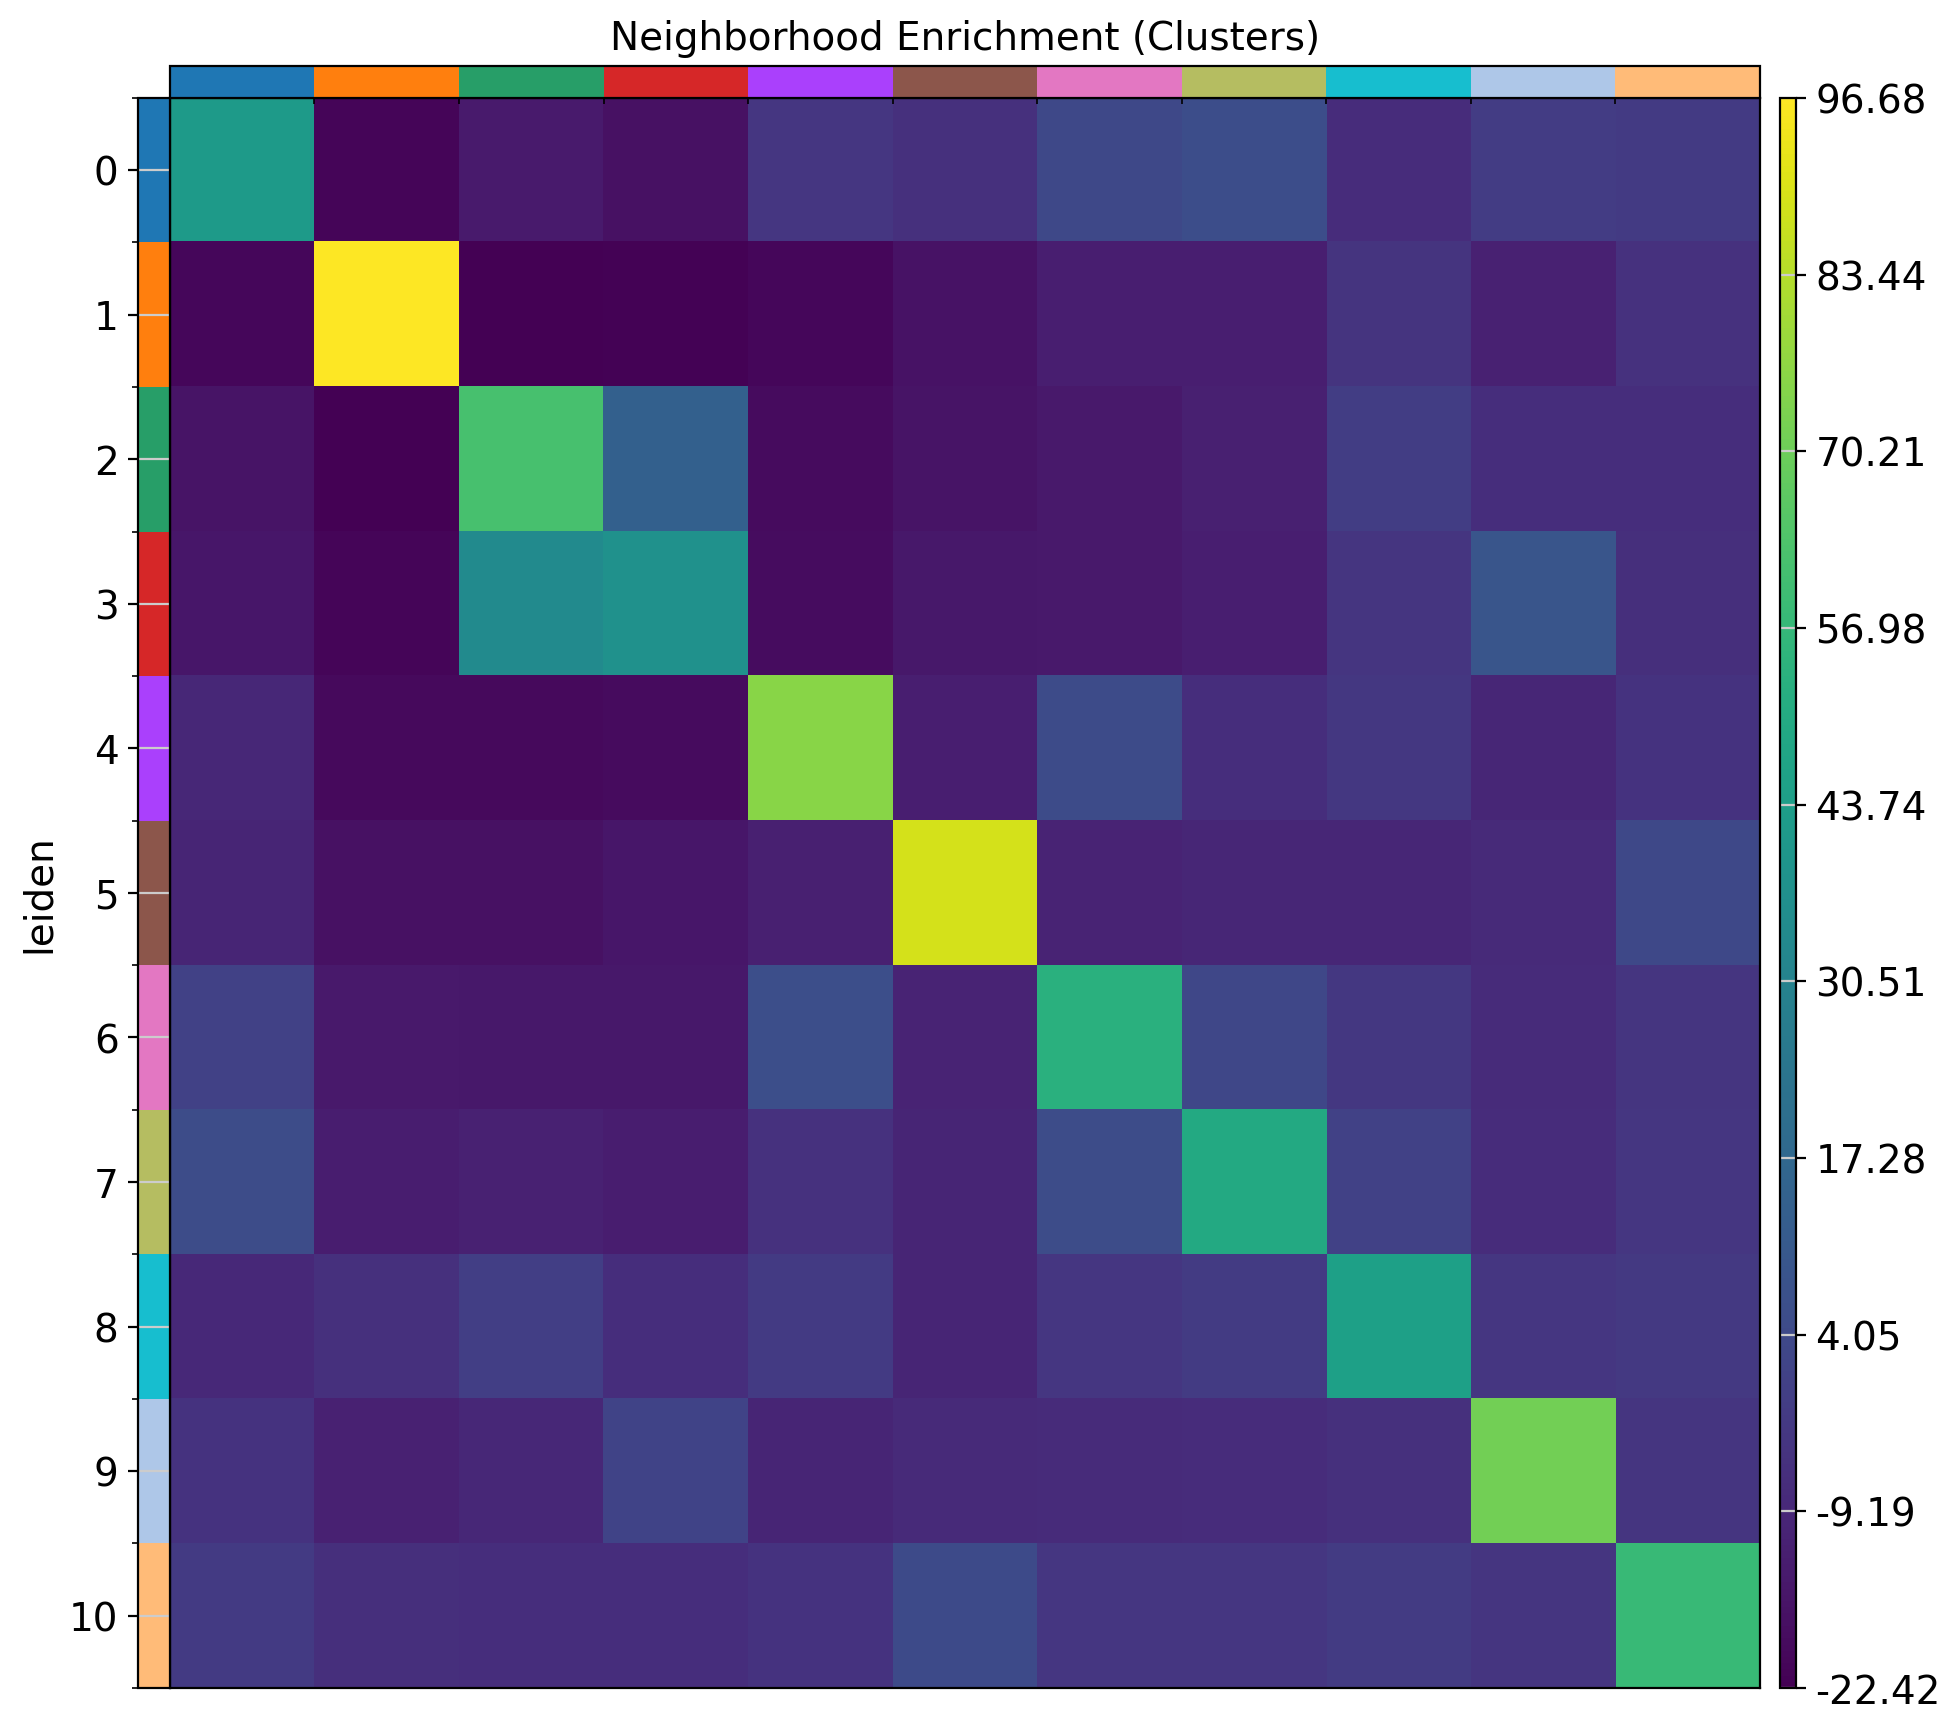

In [6]:
# Plot neighborhood enrichment
fig, ax = plt.subplots(figsize=(10, 10))
sq.pl.nhood_enrichment(
    adata,
    cluster_key='leiden',
    ax=ax,
    title='Neighborhood Enrichment (Clusters)'
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nhood_enrichment_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Extract enrichment matrix
enrichment = adata.uns['leiden_nhood_enrichment']['zscore']
enrichment_df = pd.DataFrame(
    enrichment,
    index=adata.obs['leiden'].cat.categories,
    columns=adata.obs['leiden'].cat.categories
)
enrichment_df

,0,1,2,3,4,5,6,7,8,9,10
0,42.684819,-20.623629,-13.766039,-16.916489,-3.410681,-5.816267,3.457298,5.861872,-7.410106,-1.436708,-2.113480
1,-20.238160,96.676169,-22.420523,-21.627760,-20.135204,-16.645170,-12.422187,-12.310703,-4.421991,-11.471265,-5.511441
2,-16.121358,-22.371051,62.173806,14.327004,-19.016952,-16.326000,-14.061471,-11.857972,-0.982889,-6.678222,-6.624557
3,-15.026378,-20.985754,34.441133,37.937808,-18.597803,-14.909105,-14.095999,-12.255345,-4.087165,9.175786,-6.494398
4,-9.009450,-19.535682,-19.547593,-19.047550,75.399686,-12.590351,4.711348,-6.965803,-3.030051,-9.817816,-4.894843
5,-10.168834,-17.043753,-17.079862,-15.068409,-11.795478,89.212165,-10.693819,-9.440298,-9.565221,-8.362055,3.571916
6,0.705570,-14.088830,-14.553635,-14.928372,6.071147,-10.603524,53.097144,2.866433,-3.326981,-7.791133,-4.018640
7,5.455374,-12.866103,-11.543133,-12.766194,-5.460363,-9.983277,5.476417,49.982100,0.388585,-7.077840,-3.552702
8,-8.749660,-5.705729,-0.540152,-6.858124,-2.377829,-9.925596,-3.649889,-1.763044,45.071011,-3.662663,-2.648499
9,-4.907501,-11.453466,-9.147217,1.502524,-9.890513,-8.336569,-7.856036,-7.241994,-5.682920,71.431629,-4.146881


## 4. Co-occurrence Analysis

In [8]:
# Compute co-occurrence
sq.gr.co_occurrence(
    adata,
    cluster_key='leiden',
    spatial_key='spatial'
)

Calculating co-occurrence probabilities for `50` intervals `1` split combinations using `1` core(s)


  0%|          | 0/1 [00:00<?, ?/s]

Adding `adata.uns['leiden_co_occurrence']`
Finish (0:00:05)


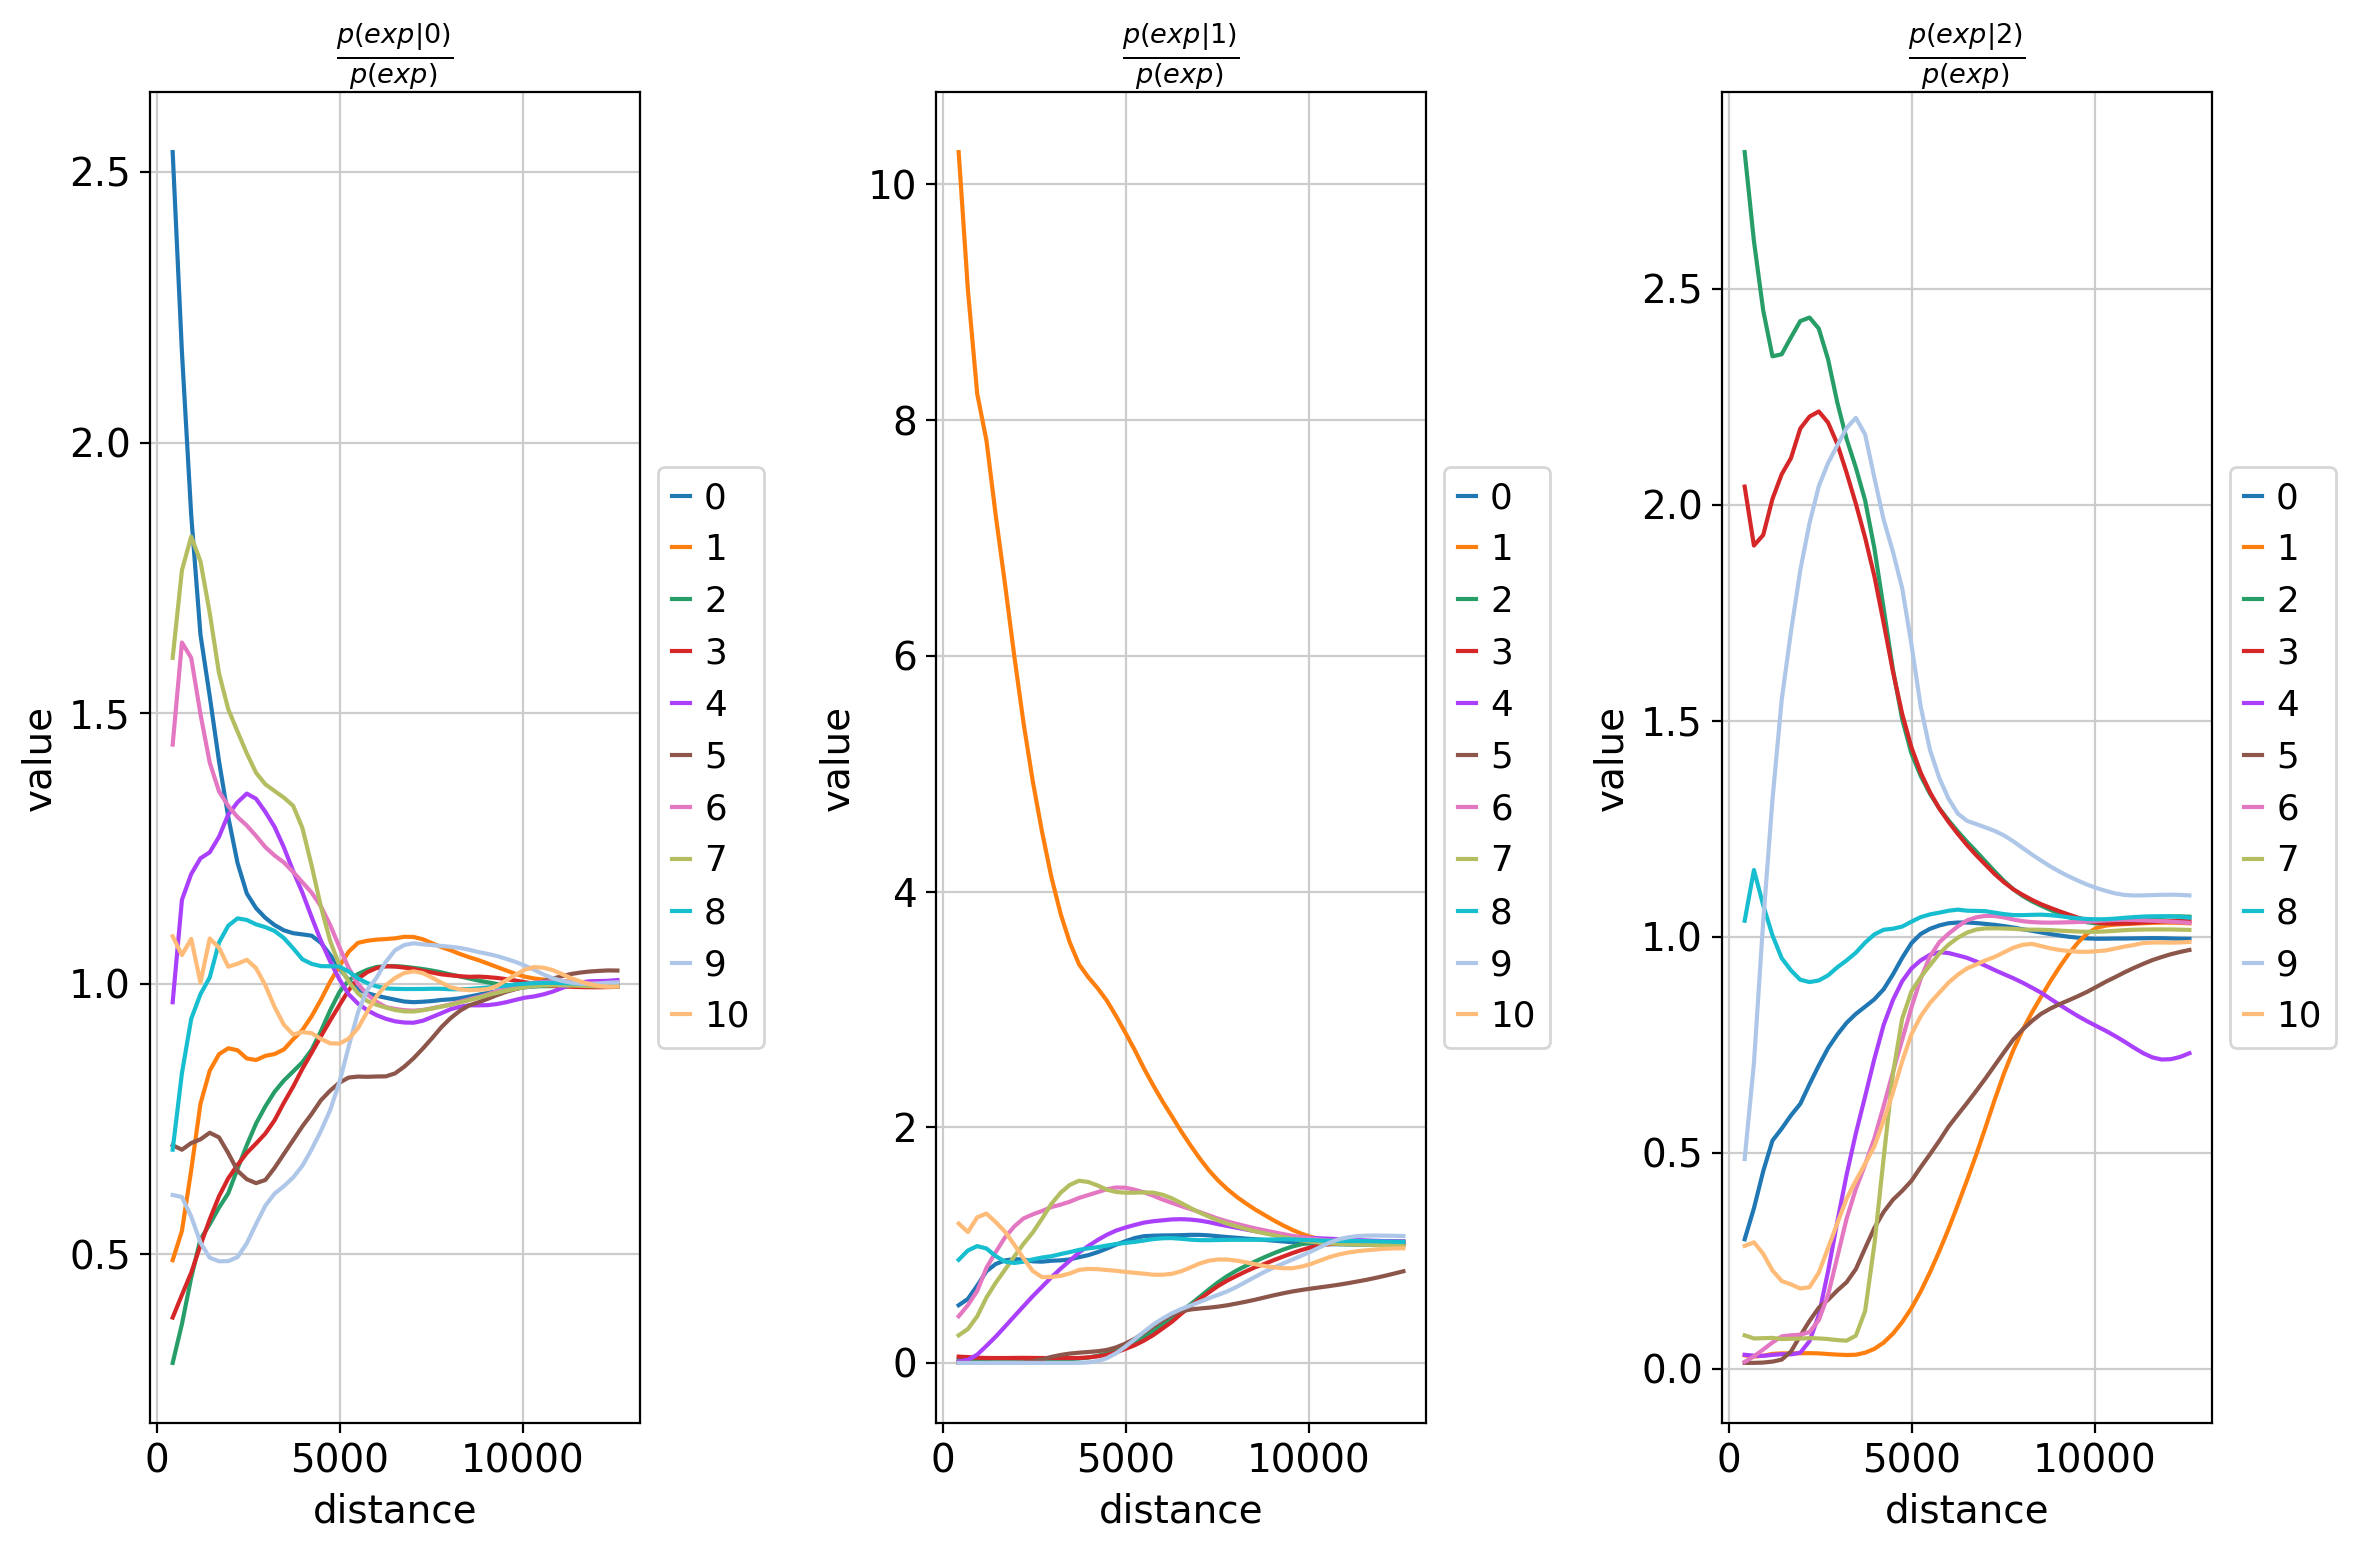

In [11]:
# Plot co-occurrence
try:
    sq.pl.co_occurrence(
        adata,
        cluster_key='leiden',
        clusters=['0', '1', '2'],
        figsize=(12, 8)
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'co_occurrence.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Co-occurrence plot error: {e}")
    print("Skipping co-occurrence visualization")

## 5. Spatial Niche Identification

In [13]:
# Get cell type proportion columns
prop_cols = [c for c in adata.obs.columns if c.endswith('_prop')]
print(f"Using {len(prop_cols)} cell type proportions for niche identification")

Using 14 cell type proportions for niche identification


In [14]:
# Extract cell type proportions
X_props = adata.obs[prop_cols].values

# Handle NaN
X_props = np.nan_to_num(X_props, nan=0)

In [15]:
# Identify spatial niches using KMeans
N_NICHES = 6

kmeans = KMeans(n_clusters=N_NICHES, random_state=42, n_init=10)
niche_labels = kmeans.fit_predict(X_props)

adata.obs['niche'] = pd.Categorical(niche_labels.astype(str))

print(f"Identified {N_NICHES} spatial niches")
print(adata.obs['niche'].value_counts())

Identified 6 spatial niches
niche
0    806
2    671
1    579
4    526
5    442
3    407
Name: count, dtype: int64


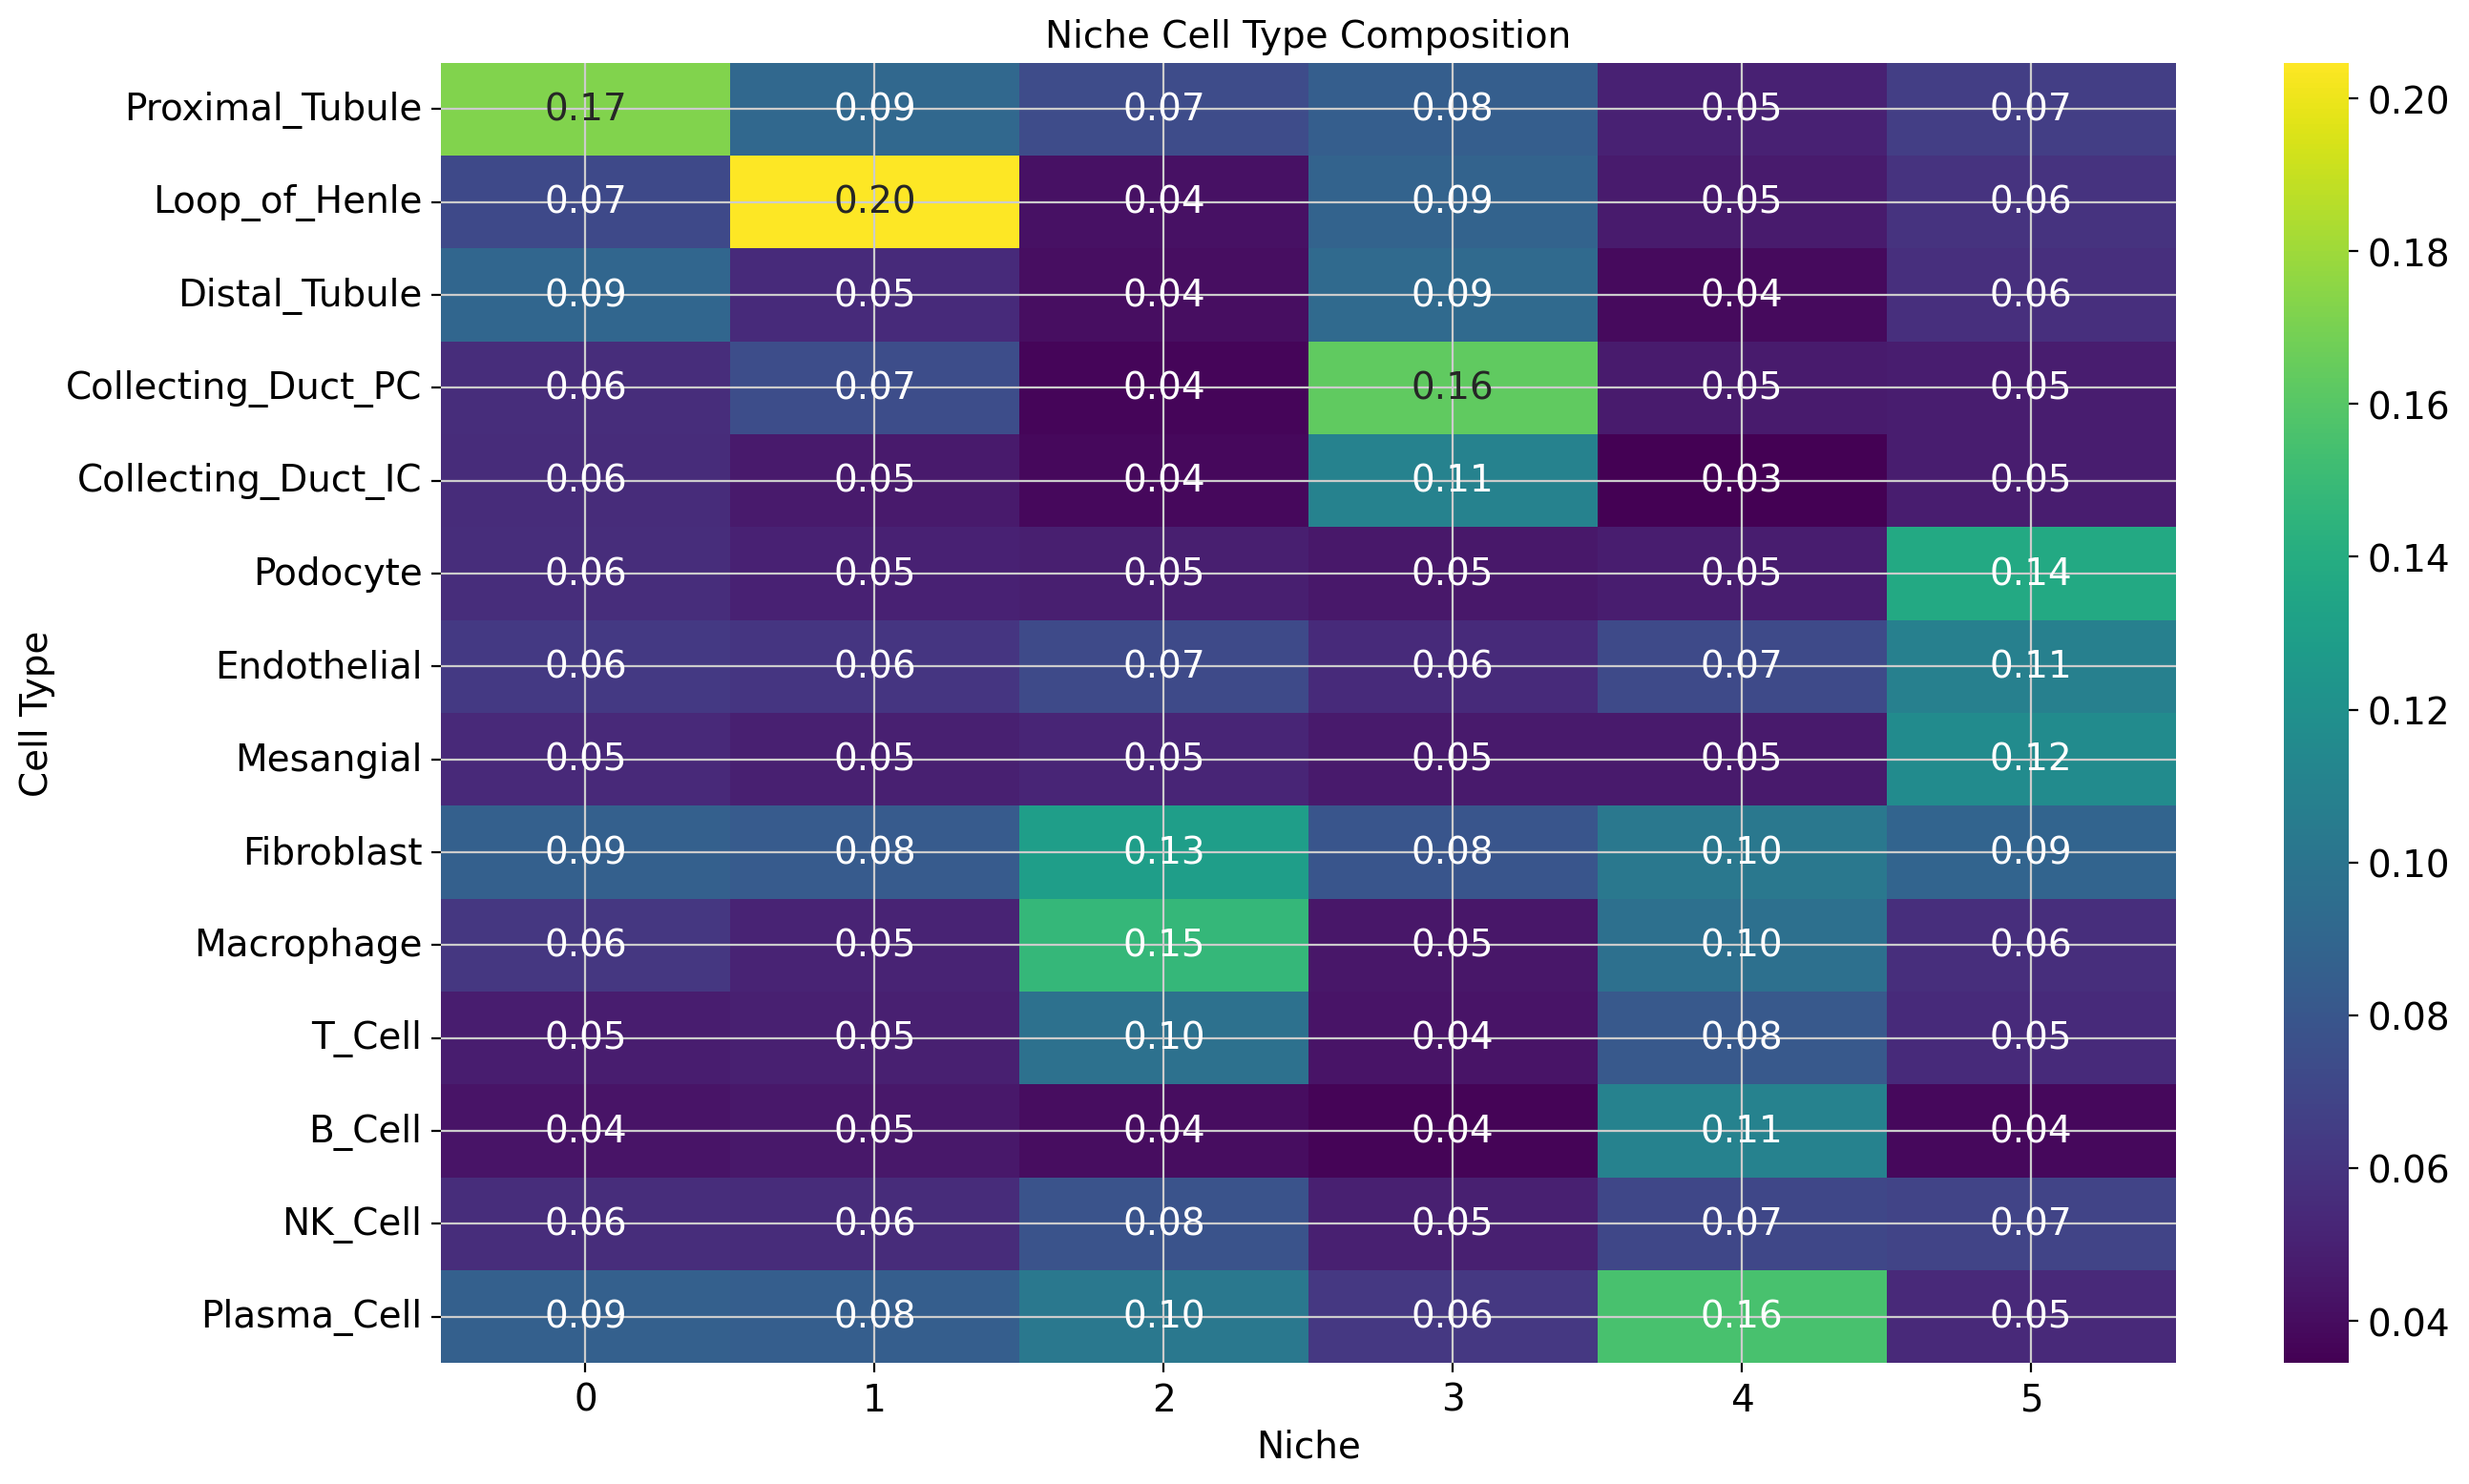

In [16]:
# Characterize niches by cell type composition
niche_composition = adata.obs.groupby('niche')[prop_cols].mean()

# Rename columns for clarity
niche_composition.columns = [c.replace('_prop', '') for c in niche_composition.columns]

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    niche_composition.T,
    cmap='viridis',
    annot=True,
    fmt='.2f',
    ax=ax
)
ax.set_title('Niche Cell Type Composition')
ax.set_xlabel('Niche')
ax.set_ylabel('Cell Type')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'niche_composition_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Save niche composition
niche_composition.to_csv(TABLES_DIR / 'niche_composition.csv')
print(f"Saved to {TABLES_DIR / 'niche_composition.csv'}")

Saved to /bigdata/godziklab/shared/Xinru/302031-spatial-kidney/results/tables/niche_composition.csv


## 6. Spatial Visualization of Niches

Saved to /bigdata/godziklab/shared/Xinru/302031-spatial-kidney/results/figures/spatial_niches_all_samples.png


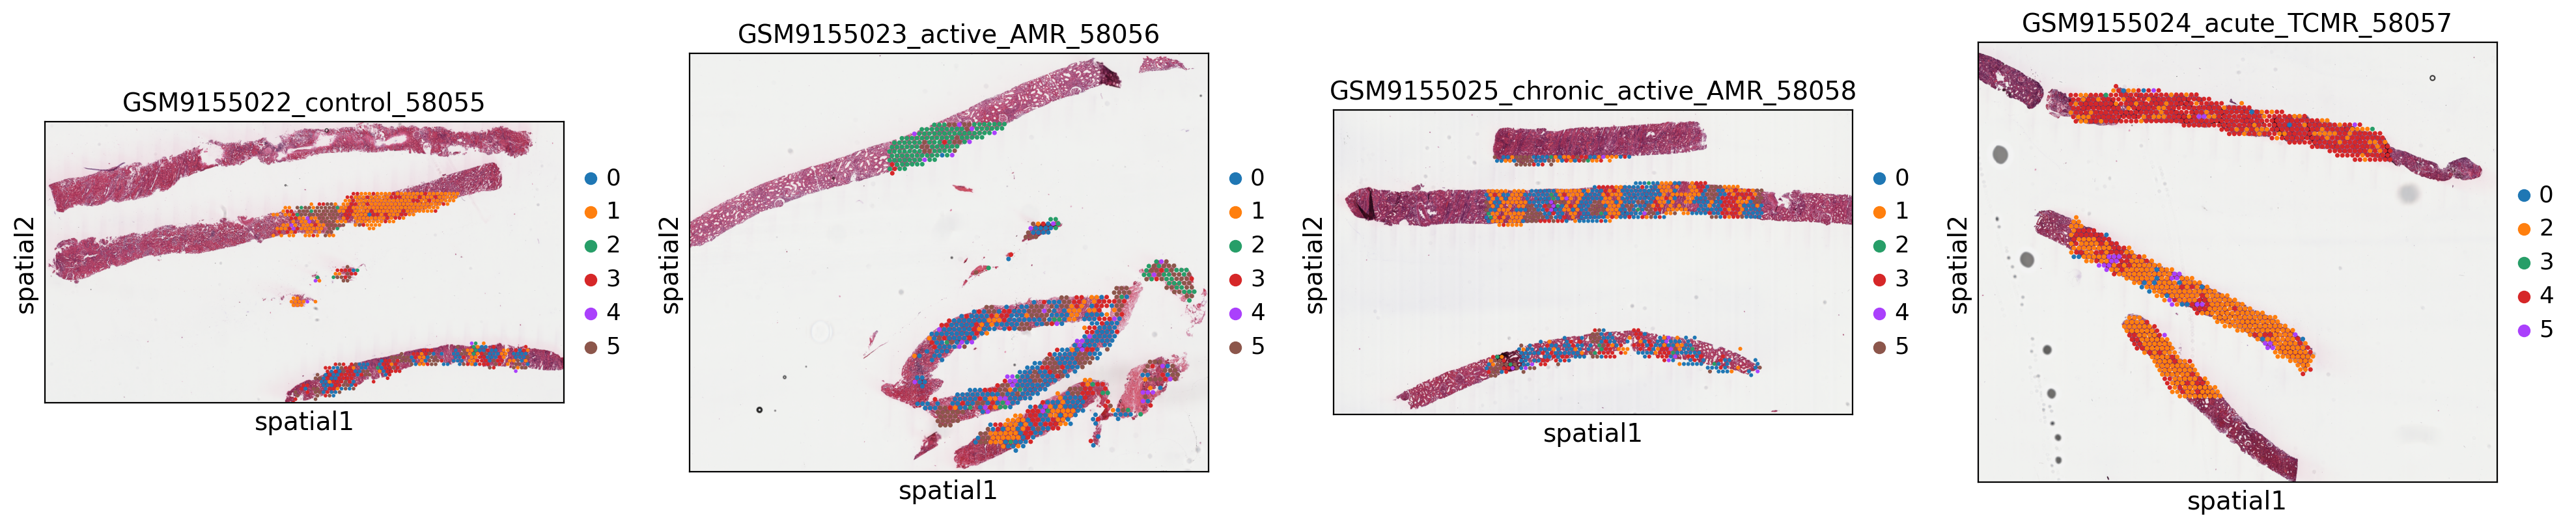

In [18]:
# Plot niches on spatial coordinates
fig = visualization.plot_spatial_clusters(
    adata,
    cluster_key='niche',
    ncols=4,
    save_path=FIGURES_DIR / 'spatial_niches_all_samples.png'
)
plt.show()

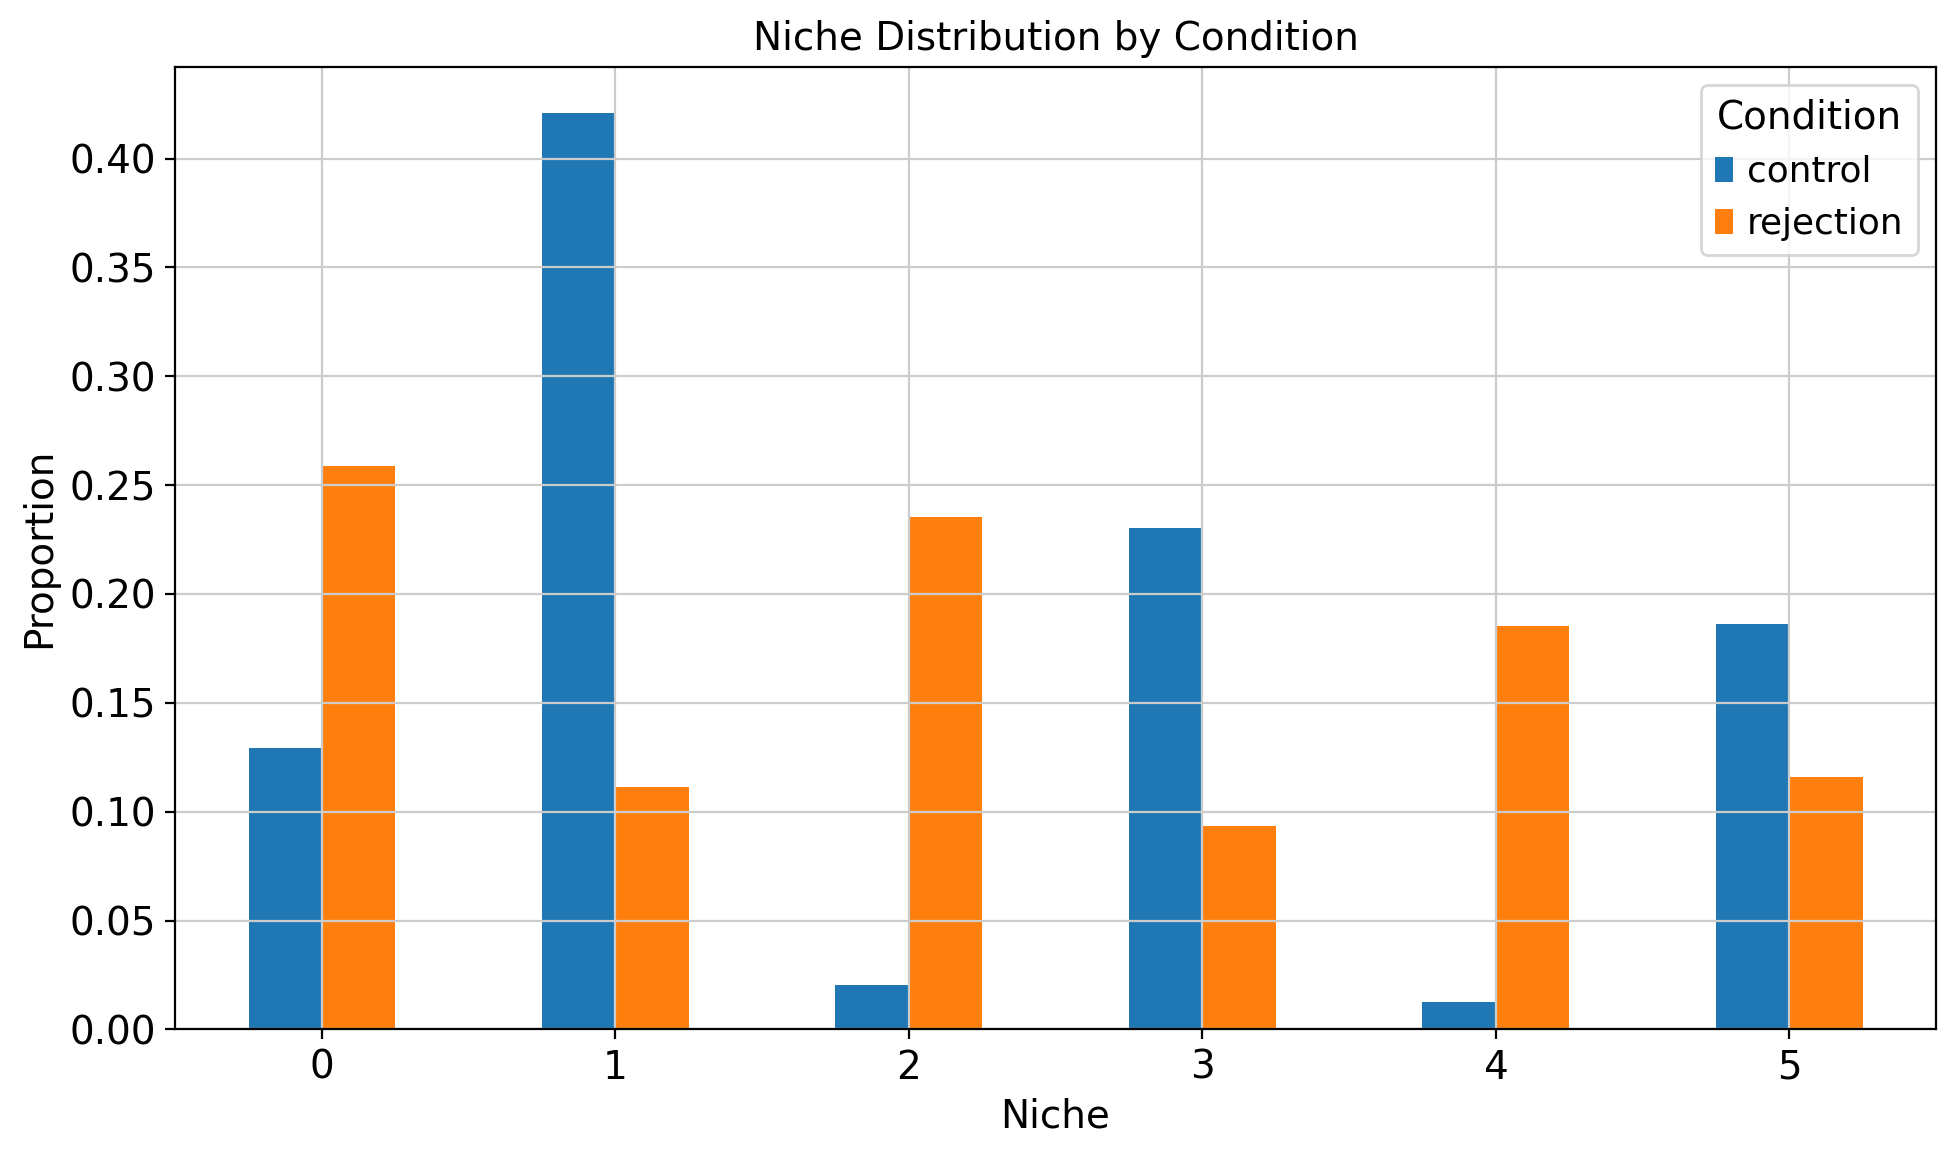

In [19]:
# Compare niche distributions by condition
niche_by_condition = pd.crosstab(
    adata.obs['niche'],
    adata.obs['condition'],
    normalize='columns'
)

fig, ax = plt.subplots(figsize=(10, 6))
niche_by_condition.plot(kind='bar', ax=ax)
ax.set_xlabel('Niche')
ax.set_ylabel('Proportion')
ax.set_title('Niche Distribution by Condition')
ax.legend(title='Condition')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'niche_distribution_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Statistical test for niche enrichment
from scipy import stats

niche_stats = []
for niche in adata.obs['niche'].cat.categories:
    control_count = ((adata.obs['niche'] == niche) & (adata.obs['condition'] == 'control')).sum()
    rejection_count = ((adata.obs['niche'] == niche) & (adata.obs['condition'] == 'rejection')).sum()
    
    total_control = (adata.obs['condition'] == 'control').sum()
    total_rejection = (adata.obs['condition'] == 'rejection').sum()
    
    # Chi-square test
    contingency = [[control_count, total_control - control_count],
                   [rejection_count, total_rejection - rejection_count]]
    chi2, pval, dof, expected = stats.chi2_contingency(contingency)
    
    niche_stats.append({
        'niche': niche,
        'control_prop': control_count / total_control,
        'rejection_prop': rejection_count / total_rejection,
        'enrichment': (rejection_count / total_rejection) / (control_count / total_control) if control_count > 0 else np.nan,
        'chi2': chi2,
        'pvalue': pval
    })

niche_stats_df = pd.DataFrame(niche_stats)
niche_stats_df['padj'] = niche_stats_df['pvalue'] * len(niche_stats_df)
niche_stats_df = niche_stats_df.sort_values('pvalue')

print("Niche enrichment in rejection vs control:")
niche_stats_df

Niche enrichment in rejection vs control:


,niche,control_prop,rejection_prop,enrichment,chi2,pvalue,padj
1,1,0.421136,0.111548,0.264874,350.931960,2.655785e-78,1.593471e-77
2,2,0.020505,0.235252,11.473062,150.142848,1.613380e-34,9.680279e-34
4,4,0.012618,0.185198,14.676975,117.265303,2.511254e-27,1.506752e-26
3,3,0.230284,0.093314,0.405214,91.436242,1.152463e-21,6.914776e-21
0,0,0.129338,0.258849,2.001343,47.516069,5.455492e-12,3.273295e-11
5,5,0.186120,0.115838,0.622386,22.125701,2.553678e-06,1.532207e-05


In [21]:
# Save niche statistics
niche_stats_df.to_csv(TABLES_DIR / 'niche_enrichment_stats.csv', index=False)
print(f"Saved to {TABLES_DIR / 'niche_enrichment_stats.csv'}")

Saved to /bigdata/godziklab/shared/Xinru/302031-spatial-kidney/results/tables/niche_enrichment_stats.csv


## 7. Niche Neighborhood Enrichment

In [22]:
# Compute neighborhood enrichment for niches
sq.gr.nhood_enrichment(adata, cluster_key='niche')

Calculating neighborhood enrichment using `1` core(s)


  0%|          | 0/1000 [00:00<?, ?/s]

Adding `adata.uns['niche_nhood_enrichment']`
Finish (0:00:00)


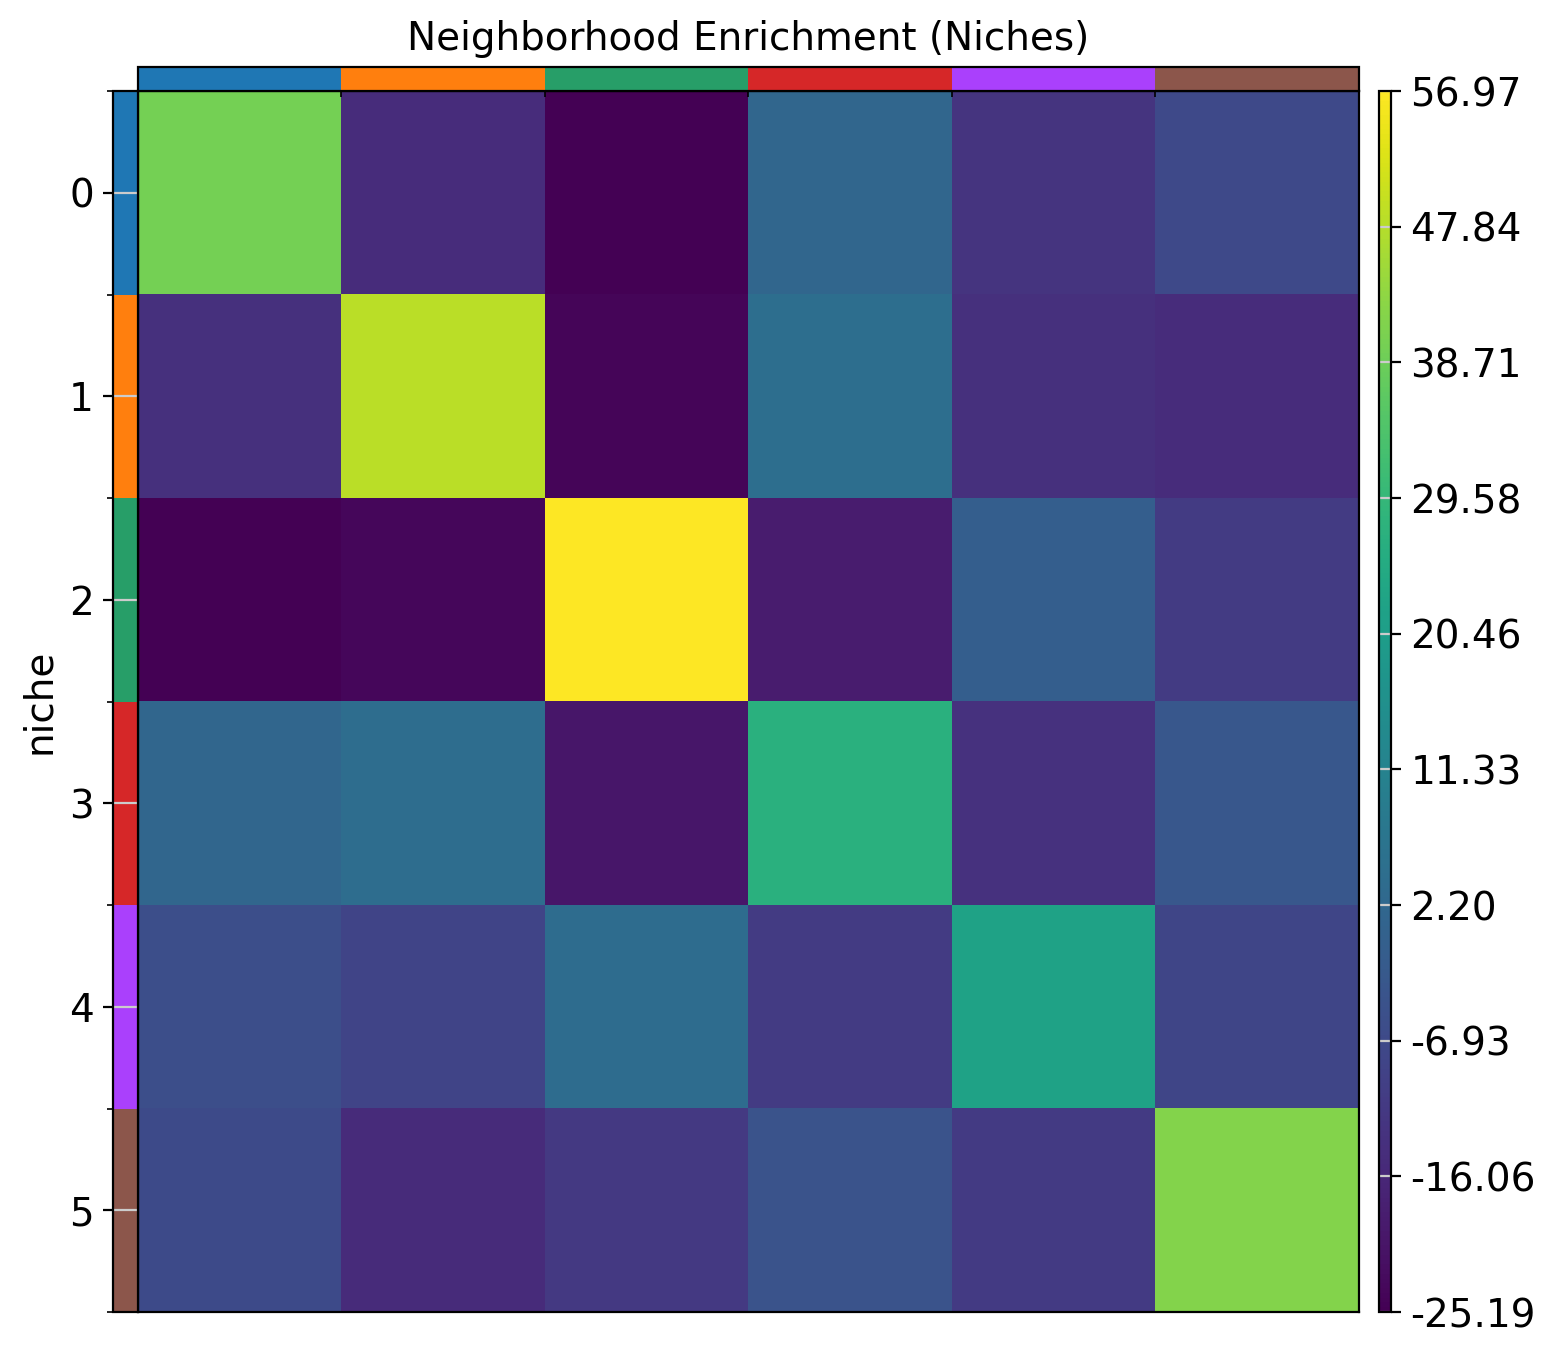

In [23]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))
sq.pl.nhood_enrichment(
    adata,
    cluster_key='niche',
    ax=ax,
    title='Neighborhood Enrichment (Niches)'
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nhood_enrichment_niches.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Results

In [24]:
# Save data with niche annotations
output_path = PROCESSED_DIR / 'adata_niches.h5ad'
adata.write(output_path)
print(f"Saved niche analysis results to: {output_path}")

Saved niche analysis results to: /bigdata/godziklab/shared/Xinru/302031-spatial-kidney/data/processed/adata_niches.h5ad


In [25]:
# Summary
print("\n" + "="*50)
print("SPATIAL NICHE ANALYSIS COMPLETE")
print("="*50)
print(f"Number of niches: {N_NICHES}")
print(f"\nNiche distribution:")
print(adata.obs['niche'].value_counts())
print(f"\nEnriched niches in rejection (p < 0.05):")
print(niche_stats_df[niche_stats_df['pvalue'] < 0.05][['niche', 'enrichment', 'pvalue']])


SPATIAL NICHE ANALYSIS COMPLETE
Number of niches: 6

Niche distribution:
niche
0    806
2    671
1    579
4    526
5    442
3    407
Name: count, dtype: int64

Enriched niches in rejection (p < 0.05):
  niche  enrichment        pvalue
1     1    0.264874  2.655785e-78
2     2   11.473062  1.613380e-34
4     4   14.676975  2.511254e-27
3     3    0.405214  1.152463e-21
0     0    2.001343  5.455492e-12
5     5    0.622386  2.553678e-06
